In [472]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set_style("darkgrid")

In [473]:
# import the data to pandas
listings = pd.read_csv('listings.csv')
neighbourhoods = pd.read_csv('neighbourhoods.csv')
reviews = pd.read_csv('reviews.csv')

In [474]:
display(listings.head(), neighbourhoods.head(), reviews.head())

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,155305,Cottage! BonPaul + Sharky's Hostel,746673,BonPaul,NaN,28806,35.578640,-82.595780,Entire home/apt,95.0,1,454,2025-06-14,2.69,8,162,16,NaN
1,197263,Tranquil Room & Private Bath,961396,Timothy,NaN,28806,35.577350,-82.638040,Private room,44.0,2,87,2024-09-08,0.56,2,73,5,NaN
2,209068,Terrace Cottage,1029919,Kevin,NaN,28804,35.617641,-82.551819,Entire home/apt,90.0,30,67,2025-05-03,0.40,1,268,2,NaN
3,246315,Asheville Dreamer's Cabin,1292070,Annie,NaN,28805,35.596150,-82.506350,Private room,61.0,7,53,2019-10-30,0.32,3,62,0,NaN
4,314540,Asheville Urban Farmhouse Entire Home 4.6 mi t...,381660,Tom,NaN,28806,35.585610,-82.627310,Entire home/apt,200.0,1,35,2025-06-13,0.22,1,139,11,NaN


,neighbourhood_group,neighbourhood
0,NaN,28704
1,NaN,28715
2,NaN,28732
3,NaN,28801
4,NaN,28803


,listing_id,date
0,155305,2011-07-31
1,155305,2011-08-23
2,155305,2011-09-19
3,155305,2011-10-28
4,155305,2012-07-01


In [475]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2876 entries, 0 to 2875
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              2876 non-null   int64  
 1   name                            2876 non-null   object 
 2   host_id                         2876 non-null   int64  
 3   host_name                       2876 non-null   object 
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   2876 non-null   int64  
 6   latitude                        2876 non-null   float64
 7   longitude                       2876 non-null   float64
 8   room_type                       2876 non-null   object 
 9   price                           2536 non-null   float64
 10  minimum_nights                  2876 non-null   int64  
 11  number_of_reviews               2876 non-null   int64  
 12  last_review                     26

In [476]:
neighbourhoods.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   neighbourhood_group  0 non-null      float64
 1   neighbourhood        8 non-null      int64  
dtypes: float64(1), int64(1)
memory usage: 260.0 bytes


In [477]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318549 entries, 0 to 318548
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   listing_id  318549 non-null  int64 
 1   date        318549 non-null  object
dtypes: int64(1), object(1)
memory usage: 4.9+ MB


In [478]:
# drop columns neighbourhood_group and license as there are no data in both columns
listings.dropna(how ='all', axis = 1, inplace = True)

In [479]:
# the two columns have successful dropped
list(listings.columns)

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365',
 'number_of_reviews_ltm']

In [480]:
# convert last_review in date 
listings["last_review"] = pd.to_datetime(listings["last_review"])
listings["id"] = listings["id"].astype(str)

In [481]:
# check the conversion
listings.dtypes

id                                        object
name                                      object
host_id                                    int64
host_name                                 object
neighbourhood                              int64
latitude                                 float64
longitude                                float64
room_type                                 object
price                                    float64
minimum_nights                             int64
number_of_reviews                          int64
last_review                       datetime64[ns]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
number_of_reviews_ltm                      int64
dtype: object

In [482]:
# drop unwanted rows
listings.drop(columns = ['latitude', 'longitude'], inplace = True)

In [483]:
list(listings.columns)

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365',
 'number_of_reviews_ltm']

In [484]:
# quick check for descriptive statistic
columns = ['price',
 'minimum_nights',
 'number_of_reviews',
'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365',
 'number_of_reviews_ltm']

listings[columns].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,2536.000000,2876.000000,2876.000000,2613.000000,2876.000000,2876.000000,2876.000000
mean,181.261435,5.907510,110.761127,2.169177,9.071627,224.535814,13.748957
std,222.095805,18.060935,154.427509,1.991770,21.872526,117.150875,18.298555
min,18.000000,1.000000,0.000000,0.020000,1.000000,0.000000,0.000000
25%,90.000000,1.000000,10.000000,0.670000,1.000000,137.000000,1.000000
50%,128.000000,2.000000,53.000000,1.620000,2.000000,254.000000,7.000000
75%,204.000000,2.000000,144.000000,3.080000,4.000000,331.000000,20.000000
max,6846.000000,730.000000,1448.000000,19.960000,108.000000,365.000000,186.000000


In [485]:
# check for duplicates
listings.duplicated().sum()

np.int64(0)

In [487]:
# check for null values
listings.isnull().sum()

id                                  0
name                                0
host_id                             0
host_name                           0
neighbourhood                       0
room_type                           0
price                             340
minimum_nights                      0
number_of_reviews                   0
last_review                       263
reviews_per_month                 263
calculated_host_listings_count      0
availability_365                    0
number_of_reviews_ltm               0
dtype: int64

In [ ]:
# there are missing values for price, last_review date and review per month. Missing price and reviews per month will be replace by their median values 
# which is more robust against outliers.Date from the review dataset will be use for analysis as they are not missing in this dataset.

In [488]:
median_price = listings['price'].median()
listings['price'] = listings['price'].fillna(median_price)

In [489]:
median_reviews_per_month = listings['reviews_per_month'].median()
listings['reviews_per_month'] = listings['reviews_per_month'].fillna(median_reviews_per_month)

In [490]:
listings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2876 entries, 0 to 2875
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              2876 non-null   object        
 1   name                            2876 non-null   object        
 2   host_id                         2876 non-null   int64         
 3   host_name                       2876 non-null   object        
 4   neighbourhood                   2876 non-null   int64         
 5   room_type                       2876 non-null   object        
 6   price                           2876 non-null   float64       
 7   minimum_nights                  2876 non-null   int64         
 8   number_of_reviews               2876 non-null   int64         
 9   last_review                     2613 non-null   datetime64[ns]
 10  reviews_per_month               2876 non-null   float64       
 11  calc

In [491]:
# let use the z-score method to detect the outliers

columns = ['price',
 'minimum_nights',
 'number_of_reviews',
'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365',
 'number_of_reviews_ltm']

for col in columns:
    z_scores = np.abs(stats.zscore(listings[col]))
    outliers_z = (z_scores > 3).sum()
    print(f"{col} :", outliers_z)

price : 40
minimum_nights : 15
number_of_reviews : 62
reviews_per_month : 49
calculated_host_listings_count : 108
availability_365 : 0
number_of_reviews_ltm : 62


In [492]:

columns = ['price',
 'minimum_nights',
 'number_of_reviews',
'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365',
 'number_of_reviews_ltm']

listings_clean = listings.copy()

for col in columns:
    lower = listings_clean[col].quantile(0.01)
    upper = listings_clean[col].quantile(0.99)
    
    listings_clean[col]= listing_clean[col].apply(lambda x : lower if x < lower else upper if x > upper else x)


In [493]:
listings_clean[columns].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,2876.000000,2876.000000,2876.000000,2876.000000,2876.000000,2876.000000,2876.000000
mean,169.039465,5.205841,109.218880,2.101996,9.071627,224.535814,13.531293
std,139.004882,9.043550,146.277466,1.824268,21.872526,117.150875,17.157320
min,38.000000,1.000000,0.000000,0.050000,1.000000,0.000000,0.000000
25%,95.000000,1.000000,10.000000,0.760000,1.000000,137.000000,1.000000
50%,128.000000,2.000000,53.000000,1.620000,2.000000,254.000000,7.000000
75%,190.000000,2.000000,144.000000,2.880000,4.000000,331.000000,20.000000
max,952.500000,30.000000,741.500000,8.550000,108.000000,365.000000,82.000000


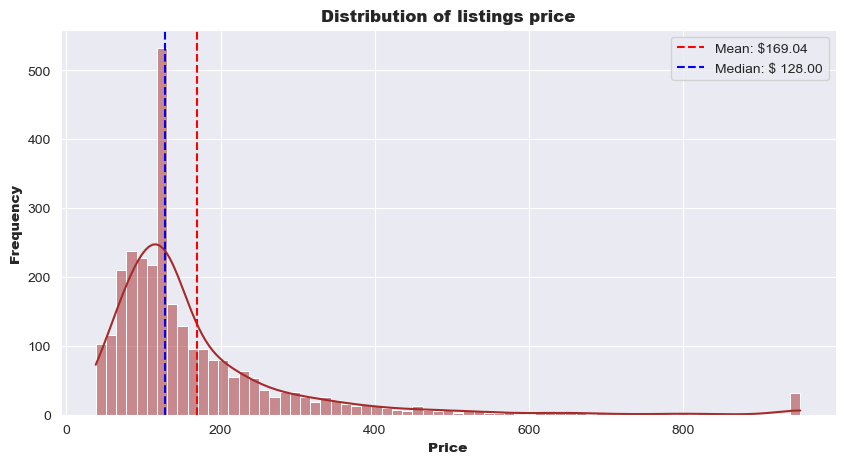

In [572]:
# calculate the average price and median price for all listings
avg_price = listings_clean['price'].mean()
median_price = listings_clean['price'].median()

plt.figure(figsize=(10,5))
sns.histplot(listings_clean, x = 'price', color = 'brown', kde = True)
plt.axvline(avg_price, color = 'red', linestyle = '--', label = f'Mean: ${avg_price:.2f}')
plt.axvline(median_price, color = 'blue', linestyle = '--', label = f'Median: ${median_price: .2f}')
plt.title('Distribution of listings price', fontweight = 'black')
plt.xlabel('Price', fontweight = 'black')
plt.ylabel('Frequency', fontweight = 'black')
plt.legend()
plt.savefig("Distribution of listings price", dpi=300, bbox_inches='tight')
plt.show()

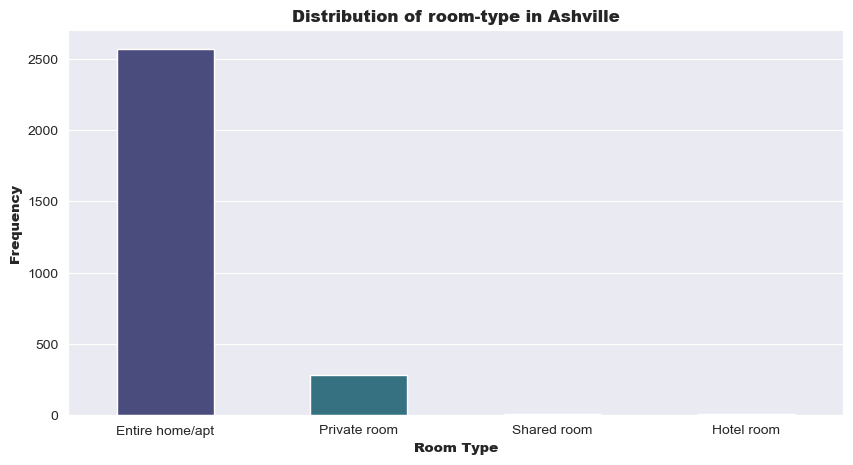

In [586]:
# show the distributions of room types

fig, ax = plt.subplots(figsize=(10,5))
sns.countplot(listings_clean, x = 'room_type', width = 0.5, hue = 'room_type', palette = 'viridis', ax = ax)
ax.set_title('Distribution of room-type in Ashville', fontweight = 'black')
ax.set_xlabel('Room Type', fontweight = 'black')
ax.set_ylabel('Frequency', fontweight = 'black')
plt.savefig('Distribution of room-type in Ashville', dpi=300, bbox_inches='tight')
plt.show()

In [415]:
# number of active listings per neighborhood

act_listings = listings_clean.groupby('neighbourhood')['id'].count().sort_values(ascending = False).reset_index()
act_listings.columns = ['listings_id', 'count']
print("="*45)
print('number of active listings per neighborhood')
print("="*45)
print(act_listings)



number of active listings per neighborhood
   listings_id  count
0        28806    807
1        28801    594
2        28803    455
3        28804    379
4        28805    282
5        28704    191
6        28715     93
7        28732     75


In [414]:
result = listings_clean['room_type'].value_counts(normalize = True)*100
print("="*50)
print('percentage distribution of Room Type in Ashville')
print("="*50)
print(result)

percentage distribution of Room Type in Ashville
room_type
Entire home/apt    89.394993
Private room        9.909597
Hotel room          0.417246
Shared room         0.278164
Name: proportion, dtype: float64


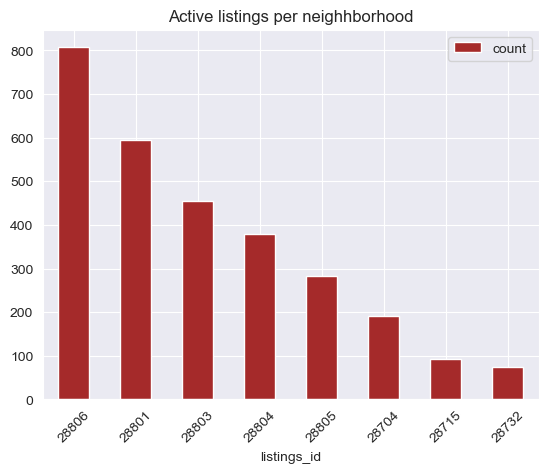

In [587]:
# graph of active listings per neighborhood.
act_listings.plot(kind = 'bar', rot = 45, x= 'listings_id', color = 'brown', title = 'Active listings per neighhborhood')
plt.savefig('Active listings per neighhborhood', dpi=300, bbox_inches='tight')
plt.show()

In [417]:
#3. Pricing Insights
# compare average price by neighborhood.
listings_clean.groupby('neighbourhood')['price'].mean().sort_values(ascending = False).round(2).head()

neighbourhood
28732    195.47
28704    179.04
28803    173.41
28805    172.89
28804    170.90
Name: price, dtype: float64

(<Axes: title={'center': 'Average price distribution by neighbourhood'}, xlabel='neighbourhood'>,
 None)

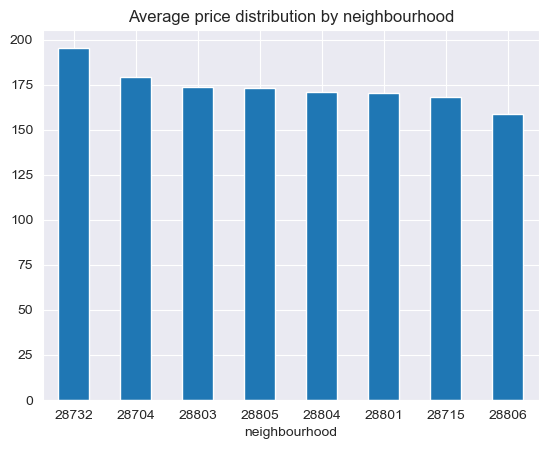

In [584]:
# graph distribution of mean price by neighbourhood
(listings_clean.groupby('neighbourhood')['price'].mean()
 .sort_values(ascending = False).
 plot(kind = 'bar', x = 'neighbourhood', rot = 0, title = 'Average price distribution by neighbourhood'),
 plt.savefig("Average price distribution by neighbourhood", dpi=300, bbox_inches='tight'))

In [ ]:
# neighbourhood 28732 and 28704 dominates the market which are suitable for high margin profit premium listings.

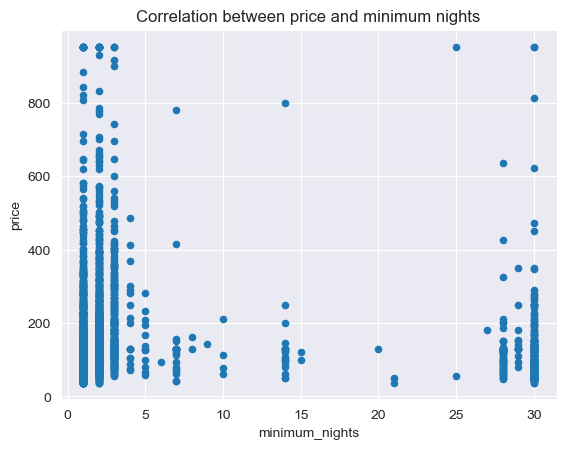

In [585]:
# check if the minimum nights affect the price
listings_clean[['minimum_nights', 'price']].plot(kind = 'scatter', x = 'minimum_nights', y = 'price', title = 'Correlation between price and minimum nights')
plt.savefig('Correlation between price and minimum nights', dpi=300, bbox_inches='tight')

In [495]:
listings_clean[['minimum_nights', 'price']].corr()

,minimum_nights,price
minimum_nights,1.0000,-0.0915
price,-0.0915,1.0000


In [578]:
listings_clean.groupby('minimum_nights')['price'].size()

minimum_nights
1.0      980
2.0     1189
3.0      281
4.0       18
5.0       13
6.0        1
7.0       23
8.0        2
9.0        1
10.0       4
14.0      19
15.0       2
20.0       1
21.0       2
25.0       2
27.0       1
28.0      64
29.0      15
30.0     258
Name: price, dtype: int64

In [577]:
# minimum nights price trend
listings_clean.groupby('minimum_nights')['price'].mean()

minimum_nights
1.0     164.039286
2.0     173.755257
3.0     213.197509
4.0     209.111111
5.0     146.769231
6.0      93.000000
7.0     148.521739
8.0     145.500000
9.0     143.000000
10.0    115.000000
14.0    151.842105
15.0    110.000000
20.0    128.000000
21.0     43.500000
25.0    503.750000
27.0    180.000000
28.0    125.218750
29.0    151.800000
30.0    131.868217
Name: price, dtype: float64

In [496]:
# Review and Demand Analysis
reviews.head()

,listing_id,date
0,155305,2011-07-31
1,155305,2011-08-23
2,155305,2011-09-19
3,155305,2011-10-28
4,155305,2012-07-01


In [497]:
# convert date to datetime
reviews['date'] = pd.to_datetime(reviews['date'])
reviews['listing_id'] = reviews['listing_id'].astype(str)

In [423]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318549 entries, 0 to 318548
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   listing_id  318549 non-null  object        
 1   date        318549 non-null  datetime64[ns]
dtypes: datetime64[ns](1), object(1)
memory usage: 4.9+ MB


In [498]:
# check for null values
reviews.isnull().sum()

listing_id    0
date          0
dtype: int64

In [499]:
# check for duplicates
reviews.duplicated().sum()

np.int64(714)

In [500]:
# remove duplicates
reviews.drop_duplicates(inplace = True)

In [502]:
# Check results
reviews.duplicated().sum()

np.int64(0)

In [204]:
#pd.set_option('display.max.rows',1000)

In [503]:
listings_clean.dtypes

id                                        object
name                                      object
host_id                                    int64
host_name                                 object
neighbourhood                              int64
room_type                                 object
price                                    float64
minimum_nights                           float64
number_of_reviews                        float64
last_review                       datetime64[ns]
reviews_per_month                        float64
calculated_host_listings_count             int64
availability_365                           int64
number_of_reviews_ltm                    float64
dtype: object

In [504]:
reviews.dtypes

listing_id            object
date          datetime64[ns]
dtype: object

In [505]:
# merge listings dataset with reviews dataset using inner join to exclude listings that are never been reviewed.

full_data = pd.merge(listings_clean.rename(columns={'id': 'listing_id'}), reviews.rename(columns = {'date': 'review_date'}), how = 'inner', on = 'listing_id')

In [506]:
full_data.shape

(317835, 15)

In [507]:
full_data.isnull().sum()

listing_id                        0
name                              0
host_id                           0
host_name                         0
neighbourhood                     0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
number_of_reviews_ltm             0
review_date                       0
dtype: int64

In [508]:
# Total number of reviews per listing
full_data.groupby('listing_id')['review_date'].count().sort_values(ascending = False).reset_index(name= 'count')

,listing_id,count
0,3314819,1444
1,2411109,1244
2,2296152,1132
3,881707,1095
4,6054250,1048
...,...,...
2608,1387031147802714863,1
2609,1384962017983252166,1
2610,1246592868183422038,1
2611,46380481,1


In [509]:
full_data.duplicated().sum()

np.int64(0)

In [510]:
# Average reviews per months
# date features for analysis
full_data['months'] = full_data['review_date'].dt.month
full_data['year'] = full_data['review_date'].dt.year
full_data['day'] = full_data['review_date'].dt.day
full_data['year_month'] = full_data['review_date'].dt.strftime('%Y-%m')
full_data['day_name'] = full_data['review_date'].dt.strftime('%a')
full_data['month_name'] = full_data['review_date'].dt.strftime('%B')
full_data['day_of_week'] = full_data['review_date'].dt.day_of_week
full_data['weekend'] = np.where(full_data['review_date'].dt.dayofweek < 5 , 'weekday', 'weekend')

In [511]:
full_data.head(2)

,listing_id,name,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,...,number_of_reviews_ltm,review_date,months,year,day,year_month,day_name,month_name,day_of_week,weekend
0,155305,Cottage! BonPaul + Sharky's Hostel,746673,BonPaul,28806,Entire home/apt,95.0,1.0,454.0,2025-06-14,...,16.0,2011-07-31,7,2011,31,2011-07,Sun,July,6,weekend
1,155305,Cottage! BonPaul + Sharky's Hostel,746673,BonPaul,28806,Entire home/apt,95.0,1.0,454.0,2025-06-14,...,16.0,2011-08-23,8,2011,23,2011-08,Tue,August,1,weekday


In [513]:
# average review per month
review_per_month = full_data.groupby('months')['listing_id'].count().reset_index(name = 'count')
review_per_month

,months,count
0,1,18525
1,2,18302
2,3,26536
3,4,26678
4,5,30038
5,6,29272
6,7,31106
7,8,27793
8,9,28037
9,10,31535


In [514]:
# which neighborhoods generate the most guest activity
full_data.groupby('neighbourhood')['review_date'].count().sort_values(ascending = False).reset_index(name = 'count')

,neighbourhood,count
0,28806,88272
1,28801,75967
2,28804,47216
3,28803,46819
4,28805,30679
5,28704,14421
6,28715,8279
7,28732,6182


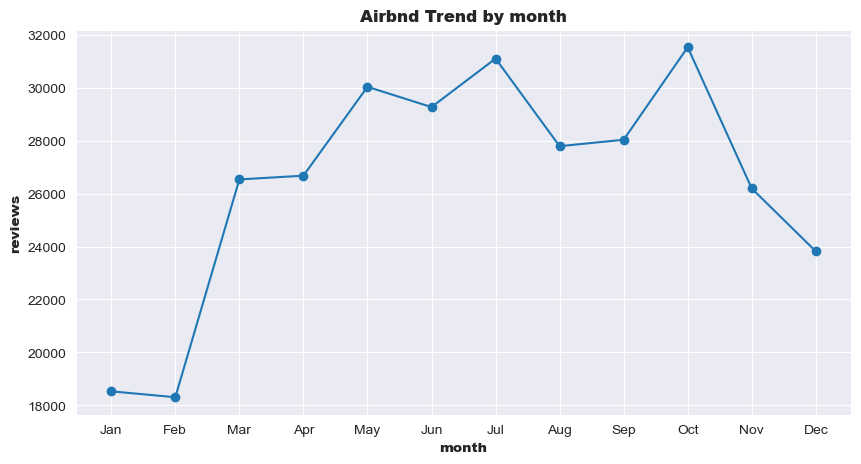

In [576]:
# demand trends
review_per_month ['months']= ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
fig, ax = plt.subplots(figsize =(10,5))
ax.plot(review_per_month['months'], review_per_month['count'],marker = 'o')
ax.set_ylabel('reviews', fontweight = 'black')
ax.set_xlabel('month', fontweight = 'black')
ax.set_title('Airbnd Trend by month' , fontweight = 'black')
plt.savefig("Airbnd Trend by month", dpi=300, bbox_inches='tight')

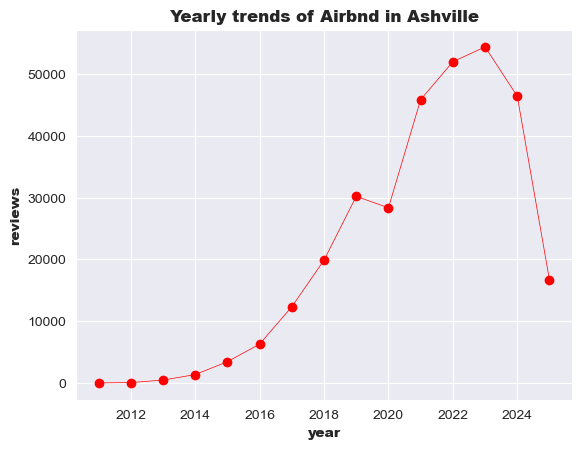

In [574]:
# by year
review_year = full_data.groupby('year')['listing_id'].count().plot(marker = 'o', linewidth = 0.5, color = 'red', ylabel ='reviews')
plt.ylabel('reviews', fontweight = 'black')
plt.xlabel('year', fontweight = 'black')
plt.title('Yearly trends of Airbnd in Ashville' , fontweight = 'black')
plt.savefig("Yearly trends of Airbnd in Ashville", dpi=300, bbox_inches='tight')

Text(0.5, 1.0, 'Airbnd Trend by day_name')

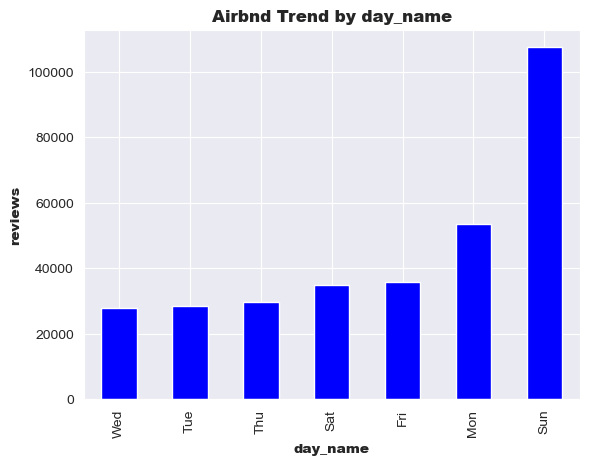

In [517]:
# trend by day_name
review_day_name = ( full_data.groupby('day_name')['listing_id'].count()
                   .sort_values(ascending = True)
                   .plot(kind = 'bar', color = 'blue')
                  )
plt.ylabel('reviews', fontweight = 'black')
plt.xlabel('day_name', fontweight = 'black')
plt.title('Airbnd Trend by day_name' , fontweight = 'black')

In [521]:
list(full_data.columns)

['listing_id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365',
 'number_of_reviews_ltm',
 'review_date',
 'months',
 'year',
 'day',
 'year_month',
 'day_name',
 'month_name',
 'day_of_week',
 'weekend']

In [529]:
# find the hosts with the most listings.

host_list = full_data.groupby(['host_id','host_name'])['calculated_host_listings_count'].max().sort_values(ascending=False).head(10)
print('='*50)
print('Host with most listing')
print('='*50)
print(host_list)

Host with most listing
host_id    host_name                       
167186184  Towns                               108
96187307   Yonder                               50
134903005  Carolina Mornings                    46
121681645  Evolve                               31
242474849  Jennifer                             28
480217041  AvantStay                            27
581734305  Asheville Cabins Of Willow Winds     25
151279507  Amanda Elizabeth                     19
46001530   Jonathan                             17
250328755  River Row Flats, Inc                 15
Name: calculated_host_listings_count, dtype: int64


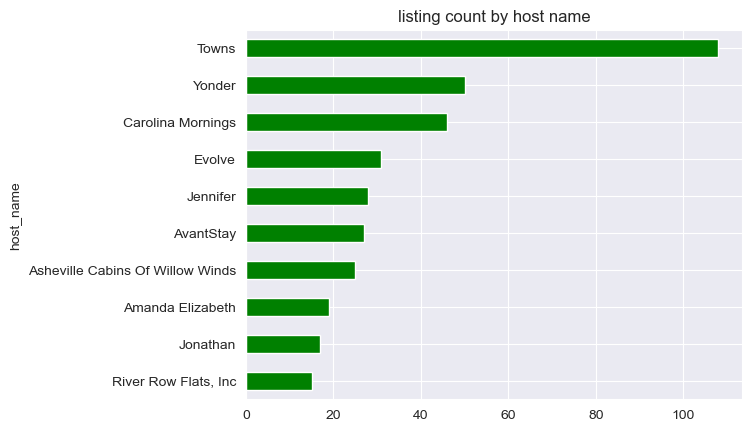

In [552]:
host_list = (full_data.groupby(['host_name'])['calculated_host_listings_count'].max()
             .sort_values(ascending=False).head(10).sort_values(ascending = True)
             .plot(kind='barh',rot = 0, color = 'green', title = 'listing count by host name')
)

In [547]:
pd.set_option('display.max.columns', 85)

In [548]:
# check whether hosts with multiple listing charge higher or lower average price

full_data['host_type'] = full_data['calculated_host_listings_count'].apply(lambda x : 'single_listing' if x ==1 else 'multiple_listing')
full_data.head(2)

,listing_id,name,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,review_date,months,year,day,year_month,day_name,month_name,day_of_week,weekend,host_type
0,155305,Cottage! BonPaul + Sharky's Hostel,746673,BonPaul,28806,Entire home/apt,95.0,1.0,454.0,2025-06-14,2.69,8,162,16.0,2011-07-31,7,2011,31,2011-07,Sun,July,6,weekend,multiple_listing
1,155305,Cottage! BonPaul + Sharky's Hostel,746673,BonPaul,28806,Entire home/apt,95.0,1.0,454.0,2025-06-14,2.69,8,162,16.0,2011-08-23,8,2011,23,2011-08,Tue,August,1,weekday,multiple_listing


In [550]:
host_type_price = full_data.groupby('host_type')['price'].mean()
host_type_price

host_type
multiple_listing    144.702368
single_listing      125.247427
Name: price, dtype: float64

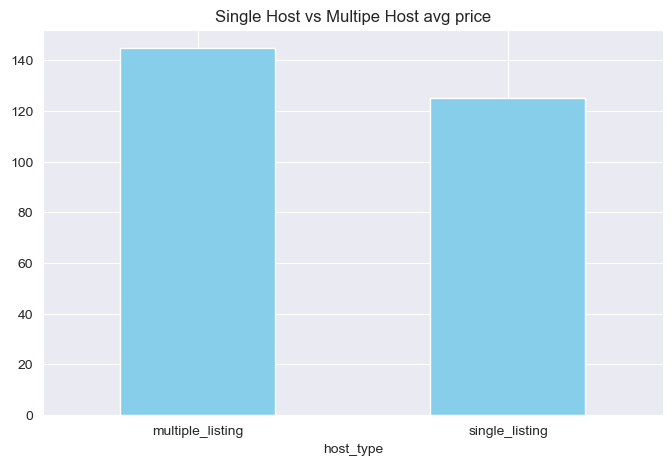

In [588]:
host_type_price.plot(kind = 'bar', rot = 0, color = 'skyblue', title = 'Single Host vs Multipe Host avg price', figsize=(8,5))
plt.savefig("Single Host vs Multipe Host avg price", dpi=300, bbox_inches='tight')